# Digital Sustainability Advisor

## Set up

### Install Libraries

In [8]:
!pip install --q crewai crewai-tools python-dotenv langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.2 MB/s eta 0:00:00


### Import Libraries

In [2]:
import os
# Environmental variables
from dotenv import load_dotenv

# CrewAI
from crewai import Task, Crew, Process, Agent, LLM
from crewai_tools import FileReadTool, WebsiteSearchTool, SerperDevTool, CodeInterpreterTool, YoutubeChannelSearchTool, YoutubeVideoSearchTool
#from crewai_tools.tools.base_tool import BaseTool
#from crewai_tools import BaseTool

from crewai import Flow
from crewai.flow.flow import listen, start

# OpenAI
from openai import OpenAI

## API Keys

In [12]:
load_dotenv('/content/sample_data/MyAPIKeys.env')
os.environ["OPENAI_API_KEY"] = "?"

## Test Connection with OpenAI

In [61]:
client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("OPENAI_API_KEY"),
)

response = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Say this is a test",
        }
    ],
    model="gpt-3.5-turbo",
)
response

ChatCompletion(id='chatcmpl-DGgxlsLJ6qbeiqSpwvw0M3UTAlW30', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='This is a test.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1772870769, model='gpt-3.5-turbo-0125', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=5, prompt_tokens=12, total_tokens=17, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [14]:
response.choices[0].message.content

'This is a test.'

In [62]:
from IPython.display import Markdown, display
import pandas as pd

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import statsmodels.api as sm

from crewai import Agent, Task, Crew
from langchain_openai import ChatOpenAI

# Background

A bank wants to help customers understand the environmental impact of their spending.

But the bank must answer:

How do we identify sustainability behaviours across millions of customers?

How do we estimate carbon impact from spending?

How do we personalise insights for each customer?

In [63]:
df = pd.read_csv("sustainable_customer_personas.csv")
df.head()

,customer_id,restaurants_spend,shopping_spend,travel_spend,groceries_spend,entertainment_spend,estimated_co2e,total_spend
0,1,89.934283,114.469428,52.953771,521.842389,55.316933,831.383036,834.516803
1,2,90.851201,101.463292,30.685405,419.356982,21.734395,628.797002,664.091275
2,3,61.839518,63.507852,69.312975,381.937896,61.350564,508.954828,637.948806
3,4,87.513960,95.974452,34.166125,351.863471,97.045564,603.132255,666.563572
4,5,84.177272,41.613195,13.436279,415.748899,74.769332,522.364867,629.744976


The **Digital Sustainability Advisor** is a specialized AI agent focused on helping customers optimize their spending for a lower carbon footprint and improved financial health. Leveraging what-if scenario analysis, this advisor analyzes how various spending choices impact both environmental footprint and personal finances. Its core function is to design sustainability and financial recommendations that encourage smarter choices, substitutions, and re-allocations within spending categories, providing personalized nudges rather than just advocating for consumption reduction. The goal is to empower users to make impactful changes that benefit both the planet and their wallet.

In [45]:
# =====================================================
# 0) Load dataset
# =====================================================
df = pd.read_csv("sustainable_customer_personas.csv")

FEATURES = [
    "restaurants_spend",
    "shopping_spend",
    "travel_spend",
    "groceries_spend",
    "entertainment_spend",
]
TARGET = "estimated_co2e"


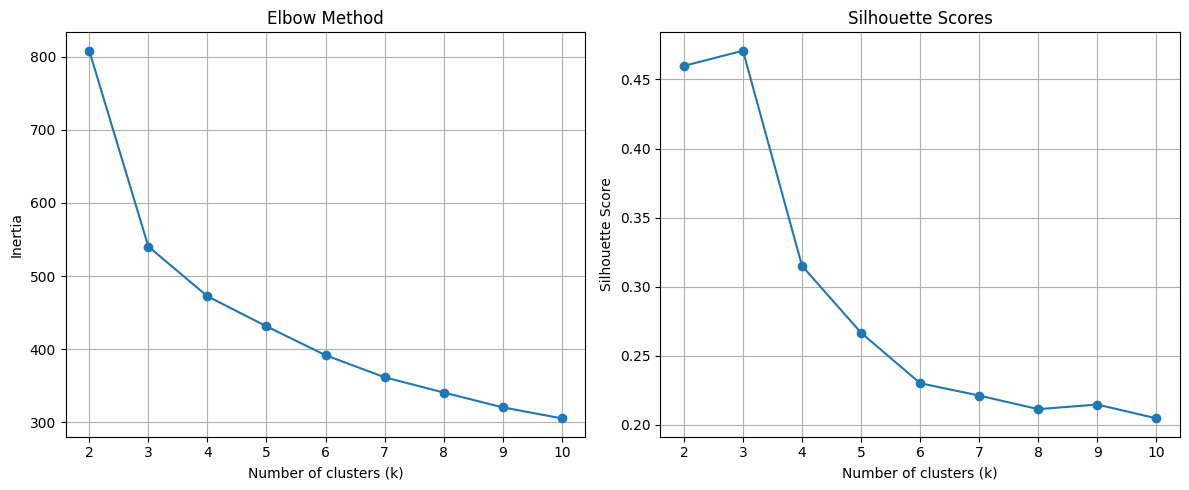


Silhouette Scores for different k values:
k=2: 0.4598
k=3: 0.4708
k=4: 0.3151
k=5: 0.2667
k=6: 0.2302
k=7: 0.2212
k=8: 0.2114
k=9: 0.2148
k=10: 0.2048


In [46]:
# -----------------------------
# Step 1 — INSIGHT
# KMeans customer segmentation for customer personas
# -----------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select relevant features from the current df for clustering
X_clustering = df[['restaurants_spend', 'shopping_spend', 'travel_spend', 'groceries_spend', 'entertainment_spend', 'total_spend', 'estimated_co2e']]

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. Determine optimal k using Elbow Method and Silhouette Score
inertia = []
silhouette_scores = []
k_range = range(2, min(11, len(X_scaled))) # K from 2 to min(10, n_samples-1)

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    inertia.append(kmeans_model.inertia_)
    # Only calculate silhouette score if more than 1 cluster
    if k > 1:
        score = silhouette_score(X_scaled, kmeans_model.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0) # Placeholder for k=1

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSilhouette Scores for different k values:")
for i, k in enumerate(k_range):
    print(f"k={k}: {silhouette_scores[i]:.4f}")

In [49]:
# Automatically select optimal k based on highest silhouette score
if len(silhouette_scores) > 0:
    optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
else:
    optimal_k = 3 # Fallback if no silhouette scores could be calculated (e.g., len(X_scaled) < 2)

print(f"\nAutomatically selected optimal k based on Silhouette Score: {optimal_k}")

# KMeans clustering with the automatically selected optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

segment_summary = (
    df.groupby('cluster')
    .mean()
    .round(2)
)

print(f"""\nCustomer Sustainability Segments (for optimal_k={optimal_k}):\n""")
print(segment_summary)


Automatically selected optimal k based on Silhouette Score: 3

Customer Sustainability Segments (for optimal_k=3):

         customer_id  restaurants_spend  shopping_spend  travel_spend  \
cluster                                                                 
0              120.5             111.64          135.19         52.51   
1              150.5             192.12          185.71        607.78   
2               90.5             303.57          244.27        124.34   

         groceries_spend  entertainment_spend  estimated_co2e  total_spend  
cluster                                                                     
0                 354.86                73.90          835.36       728.09  
1                 222.51               167.52         1783.46      1375.63  
2                 257.58               201.19         1204.90      1130.95  


In [50]:
# -----------------------------
# Step 2 — FORESIGHT
# Predict estimated_co2e from spend features (Linear Regression + diagnostics)
# -----------------------------

import statsmodels.api as sm

# Define features (X) and target (y) for OLS model
X_ols = sm.add_constant(df[FEATURES]) # Add a constant (intercept) to the features
y_ols = df[TARGET]

# Fit the OLS (Ordinary Least Squares) model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Create a compact diagnostics summary (business-friendly) for CrewAI
diag = {
    "R2": float(ols_model.rsquared),
    "Adj_R2": float(ols_model.rsquared_adj),
    "F_pvalue": float(ols_model.f_pvalue),
}

# Create a coefficient table for CrewAI
coef_table = (
    pd.DataFrame({
        "feature": ols_model.params.index,
        "coef": ols_model.params.values,
        "p_value": ols_model.pvalues.values
    })
    .query("feature != 'const'") # Exclude the constant term
    .sort_values("coef", ascending=False)
)

# Pick top drivers by coefficient magnitude (positive drivers) for CrewAI
top_drivers = coef_table.head(3).round(4)

# Attach predictions to the main DataFrame for potential use in Action step
df["predicted_co2e"] = ols_model.predict(X_ols)

# Create prediction_summary for use in CrewAI tasks
prediction_summary = df[['customer_id', 'estimated_co2e', 'predicted_co2e']].head(5).round(2)

In [51]:
print("\nLinear Regression Diagnostics (Summary of OLS model):\n")
print(ols_model.summary())

print("\nSample Predicted Carbon Impact (first 5 customers):\n")
display(prediction_summary)


Linear Regression Diagnostics (Summary of OLS model):

                            OLS Regression Results                            
Dep. Variable:         estimated_co2e   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     403.4
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          7.77e-113
Time:                        07:16:27   Log-Likelihood:                -1523.8
No. Observations:                 240   AIC:                             3060.
Df Residuals:                     234   BIC:                             3080.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

,customer_id,estimated_co2e,predicted_co2e
0,1,831.38,872.03
1,2,628.80,769.26
2,3,508.95,776.73
3,4,603.13,770.47
4,5,522.36,711.56


In [52]:
# -----------------------------
# Step 3 — ACTION
# What-if simulation
# -----------------------------

def what_if_scenarios(customer_row: pd.Series) -> pd.DataFrame:
    """
    Explainable scenario testing:
    - Reduce Travel by 20%
    - Reduce Restaurants by 20%
    - Reduce Shopping by 20%
    - Reduce all 3 by 15%
    """
    base = customer_row[FEATURES].copy()
    scenarios = []

    def predict_from_features(feat_series: pd.Series, original_index: int) -> float:
        # Convert series to DataFrame with appropriate index for sm.add_constant
        x_df = pd.DataFrame([feat_series.values], columns=FEATURES, index=[original_index])
        x = sm.add_constant(x_df, has_constant="add")
        return float(ols_model.predict(x).loc[original_index])

    # Get baseline prediction
    baseline_predicted_co2e = predict_from_features(base, customer_row.name)
    scenarios.append(("Baseline (no change)", baseline_predicted_co2e))

    # Scenario 1: Reduce travel spend by 20%
    s1 = base.copy()
    s1["travel_spend"] *= 0.8
    scenarios.append(("Reduce travel 20%", predict_from_features(s1, customer_row.name)))

    # Scenario 2: Reduce restaurants spend by 20%
    s2 = base.copy()
    s2["restaurants_spend"] *= 0.8
    scenarios.append(("Reduce restaurants 20%", predict_from_features(s2, customer_row.name)))

    # Scenario 3: Reduce shopping spend by 20%
    s3 = base.copy()
    s3["shopping_spend"] *= 0.8
    scenarios.append(("Reduce shopping 20%", predict_from_features(s3, customer_row.name)))

    # Scenario 4: Reduce travel, restaurants, and shopping by 15%
    s4 = base.copy()
    s4["travel_spend"] *= 0.85
    s4["restaurants_spend"] *= 0.85
    s4["shopping_spend"] *= 0.85
    scenarios.append(("Reduce travel/restaurants/shopping 15%", predict_from_features(s4, customer_row.name)))

    # Create DataFrame from scenarios
    out = pd.DataFrame(scenarios, columns=["scenario", "predicted_co2e"])
    out["reduction_vs_baseline"] = out["predicted_co2e"].iloc[0] - out["predicted_co2e"]
    out["reduction_pct"] = 100 * out["reduction_vs_baseline"] / out["predicted_co2e"].iloc[0]
    return out.round(2)

In [53]:
# Ask user for customer ID
chosen_customer_id = int(input("Enter a customer ID to test (e.g., 50): "))

# Filter df to select the chosen customer
# Check if the customer ID exists in the DataFrame
if chosen_customer_id in df['customer_id'].values:
    sample_customer = df[df['customer_id'] == chosen_customer_id].iloc[0]
else:
    print(f"Customer ID {chosen_customer_id} not found. Selecting a random customer instead.")
    sample_customer = df.sample(1, random_state=80).iloc[0] # Fallback to random if not found

scenario_table = what_if_scenarios(sample_customer)

# Identify best scenario (largest reduction)
# Exclude the baseline row when finding the best reduction scenario
best_row = scenario_table.iloc[1:].sort_values("reduction_vs_baseline", ascending=False).iloc[0]

# Store the best action details
best_action = {
    "customer_id": int(sample_customer["customer_id"]),
    "cluster": int(sample_customer["cluster"]),
    "baseline_predicted_co2e": float(scenario_table.iloc[0]["predicted_co2e"]),
    "best_scenario": str(best_row["scenario"]),
    "new_predicted_co2e": float(best_row["predicted_co2e"]),
    "reduction_abs": float(best_row["reduction_vs_baseline"]),
    "reduction_pct": float(best_row["reduction_pct"]),
    "spend_snapshot": {k: float(sample_customer[k]) for k in FEATURES},
}
print("\nSample Customer Details:")
print(f"Customer ID: {best_action['customer_id']}")
print(f"Assigned Cluster: {best_action['cluster']}")
print(f"Baseline Predicted CO2e: {best_action['baseline_predicted_co2e']:.2f}")
print("\nWhat-If Scenario Table:")
display(scenario_table)

Enter a customer ID to test (e.g., 50): 50

Sample Customer Details:
Customer ID: 50
Assigned Cluster: 0
Baseline Predicted CO2e: 689.61

What-If Scenario Table:


,scenario,predicted_co2e,reduction_vs_baseline,reduction_pct
0,Baseline (no change),689.61,0.00,0.00
1,Reduce travel 20%,677.85,11.77,1.71
2,Reduce restaurants 20%,677.12,12.49,1.81
3,Reduce shopping 20%,683.76,5.86,0.85
4,Reduce travel/restaurants/shopping 15%,667.03,22.59,3.28


In [54]:
print("\nBest Action for this Customer:")
for key, value in best_action.items():
    if key != "spend_snapshot":
        print(f"{key}: {value}")
print(f"Spend Snapshot: {best_action['spend_snapshot']}")


Best Action for this Customer:
customer_id: 50
cluster: 0
baseline_predicted_co2e: 689.61
best_scenario: Reduce travel/restaurants/shopping 15%
new_predicted_co2e: 667.03
reduction_abs: 22.59
reduction_pct: 3.28
Spend Snapshot: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936, 'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend': 73.39345097660077}


In [55]:
# -----------------------------
# CrewAI Agents
# -----------------------------

llm = ChatOpenAI(model="gpt-4o-mini")

insight_agent = Agent(
    role="Sustainability Insight Analyst",
    goal="Explain customer sustainability segments",
    backstory="You analyse customer transaction patterns to identify sustainability behaviour segments.",
    llm=llm,
    verbose=True
)

foresight_agent = Agent(
    role="Carbon Impact Forecast Specialist",
    goal="Explain predicted future environmental impact",
    backstory="You specialise in predictive analytics for sustainability forecasting.",
    llm=llm,
    verbose=True
)

action_agent = Agent(
    role="Sustainable Lifestyle Advisor",
    goal="Recommend behavioural changes to reduce carbon footprint",
    backstory="You design sustainability recommendations and personalised nudges.",
    llm=llm,
    verbose=True
)

In [56]:
# -----------------------------
# CrewAI Tasks
# -----------------------------

insight_task = Task(
    description=f"""
Interpret the following customer sustainability segmentation results:

{segment_summary.to_string()}

Explain the meaning of the segments in business language.
Identify which segments represent higher carbon impact behaviour.
""",
    expected_output="A detailed explanation of customer sustainability segments, their business meaning, and identification of segments with higher carbon impact behavior.",
    agent=insight_agent
)

foresight_task = Task(
    description=f"""
Interpret the predicted carbon impact below:

{prediction_summary.to_string()}

Explain what this means for the customer's future environmental impact.
Identify the categories likely driving the emissions increase.
""",
    expected_output="A clear interpretation of the predicted carbon impact, including future environmental implications and the categories contributing to increased emissions.",
    agent=foresight_agent
)

action_task = Task(
    description=f"""
Using the what-if analysis results below:

{str(best_action)}

Create a short personalised email encouraging the customer to adopt lower-carbon spending behaviour.
Provide 3 actionable recommendations.

Customer context:
- customer_id: {best_action['customer_id']}
- assigned_cluster: {best_action['cluster']}
- current spend snapshot: {best_action['spend_snapshot']}
- baseline predicted CO2e: {best_action['baseline_predicted_co2e']:.2f}

What-if scenarios:
{scenario_table.to_string(index=False)}

Best scenario:
- {best_action['best_scenario']}
- new predicted CO2e: {best_action['new_predicted_co2e']:.2f}
- estimated reduction: {best_action['reduction_pct']:.1f}%

Email requirements:
- Subject line + greeting
- 2 lines explaining the insight (top drivers)
- 3 bullet actions (very practical)
- 1 friendly CTA line (e.g., "Check your sustainability tips in-app")
- Tone: supportive, not guilt-inducing
""",
    expected_output="A set of 3 bullet-point recommendations tailored to the customer persona and a personalized email draft to encourage sustainable consumption.",
    agent=action_agent
)

In [57]:
# -----------------------------
# Crew Execution
# -----------------------------

crew = Crew(
    agents=[insight_agent, foresight_agent, action_agent],
    tasks=[insight_task, foresight_task, action_task],
    verbose=True
)

result = crew.kickoff()

print("\nFinal AI Recommendation\n")
print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 7bf13d33-2987-4993-93c1-9c1dc67c40e2                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│  ID: fccb4957-0c4b-48f8-a1a1-0824db7d8d4d                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The customer sustainability segmentation results present an insightful view into distinct customer behavior    │
│  patterns in relation to sustainability, as indicated through their spending habits across various categories.  │
│  Each segment, or cluster, delineates specific characteristics around customer spending that are pertinent for  │
│  understanding their overall sustainability impact.                                                             │
│                                                                                                                 │
│  ### Segment Analysis:                                                                                          │
│                                                                                                                 │
│  **Cluster 0**                                                                                                  │
│  - **Customer ID:** 120.5                                                                                       │
│  - **Restaurants Spend:** 111.64                                                                                │
│  - **Shopping Spend:** 135.19                                                                                   │
│  - **Travel Spend:** 52.51                                                                                      │
│  - **Groceries Spend:** 354.86                                                                                  │
│  - **Entertainment Spend:** 73.90                                                                               │
│  - **Estimated CO2e:** 73.90                                                                                    │
│  - **Total Spend:** 835.36                                                                                      │
│                                                                                                                 │
│  **Interpretation:**                                                                                            │
│  Cluster 0 comprises customers with moderate overall spending and relatively low environmental impact. Their    │
│  greatest expenditure is on groceries, which typically suggests a focus on food, likely indicating preference   │
│  for home-cooked meals rather than dining out. The low travel spend and moderate entertainment spend further    │
│  highlight a lifestyle that may prioritize local activities and minimizes carbon emissions related to travel.   │
│                                                                                                                 │
│  **Cluster 1**                                                                                                  │
│  - **Customer ID:** 150.5                                                                                       │
│  - **Restaurants Spend:** 192.12                                                                                │
│  - **Shopping Spend:** 185.71                                                                                   │
│  - **Travel Spend:** 607.78                                                                                     │
│  - **Groceries Spend:** 222.51                                                                                  │
│  - **Entertainment Spend:** 222.51                     

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainable Lifestyle Advisor                                                                           │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Using the what-if analysis results below:                                                                      │
│                                                                                                                 │
│  {'customer_id': 50, 'cluster': 0, 'baseline_predicted_co2e': 689.61, 'best_scenario': 'Reduce                  │
│  travel/restaurants/shopping 15%', 'new_predicted_co2e': 667.03, 'reduction_abs': 22.59, 'reduction_pct':       │
│  3.28, 'spend_snapshot': {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,         │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}}                                                                                            │
│                                                                                                                 │
│  Create a short personalised email encouraging the customer to adopt lower-carbon spending behaviour.           │
│  Provide 3 actionable recommendations.                                                                          │
│                                                                                                                 │
│  Customer context:                                                                                              │
│  - customer_id: 50                                                                                              │
│  - assigned_cluster: 0                                                                                          │
│  - current spend snapshot: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,       │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}                                                                                             │
│  - baseline predicted CO2e: 689.61                                                                              │
│                                                                                                                 │
│  What-if scenarios:                                                                                             │
│                                scenario  predicted_co2e  reduction_vs_baseline  reduction_pct                   │
│                    Baseline (no change)          689.61                   0.00           0.00                   │
│                       Reduce travel 20%          677.85                  11.77           1.71                   │
│                  Reduce restaurants 20%          677.12                  12.49           1.81                   │
│                     Reduce shopping 20%          683.76                   5.86           0.85                   │
│  Reduce travel/restaurants/shopping 15%          667.03                  22.59           3.28                   │
│                                                                                                                 │
│  Best scenario:                                                                                                 │
│  - Reduce travel/restaurants/shopping 15%                                                                       │
│  - new predicted CO2e: 667.03                          

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainable Lifestyle Advisor                                                                           │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Subject: Small Changes, Big Impact on Your Carbon Footprint                                                    │
│                                                                                                                 │
│  Hi there,                                                                                                      │
│                                                                                                                 │
│  I hope this message finds you well! I've been reviewing your spending patterns, and I noticed that your main   │
│  drivers of carbon emissions come from travel, dining out, and shopping. Improving these habits can lead to a   │
│  more sustainable lifestyle while also benefiting your wallet!                                                  │
│                                                                                                                 │
│  To help you reduce your carbon footprint by approximately 3.3%, here are three actionable recommendations:     │
│                                                                                                                 │
│  - **Dine In More Often**: Consider cooking at home instead of eating out. This not only reduces emissions but  │
│  can also save you money. Try exploring new recipes or meal prep to make it easier!                             │
│                                                                                                                 │
│  - **Opt for Local Experiences**: Instead of traveling far for entertainment, seek out local activities or      │
│  events. This can significantly cut down on travel emissions while allowing you to discover new interests in    │
│  your community.                                                                                                │
│                                                                                                                 │
│  - **Mindful Shopping**: When you do shop, aim for quality over quantity. Try to buy second-hand or             │
│  sustainably made products, which can lower your impact and promote a circular economy.                         │
│                                                                                                                 │
│  You're already on a great path toward sustainability, and every little effort counts! If you're looking for    │
│  more tips, check your sustainability tips in-app.                                                              │
│                                                                                                                 │
│  Best regards,                                                                                                  │
│  [Your Name]                                                                                                    │
│  Sustainable Lifestyle Advisor                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Using the what-if analysis results below:                                                                      │
│                                                                                                                 │
│  {'customer_id': 50, 'cluster': 0, 'baseline_predicted_co2e': 689.61, 'best_scenario': 'Reduce                  │
│  travel/restaurants/shopping 15%', 'new_predicted_co2e': 667.03, 'reduction_abs': 22.59, 'reduction_pct':       │
│  3.28, 'spend_snapshot': {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,         │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}}                                                                                            │
│                                                                                                                 │
│  Create a short personalised email encouraging the customer to adopt lower-carbon spending behaviour.           │
│  Provide 3 actionable recommendations.                                                                          │
│                                                                                                                 │
│  Customer context:                                                                                              │
│  - customer_id: 50                                                                                              │
│  - assigned_cluster: 0                                                                                          │
│  - current spend snapshot: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,       │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}                                                                                             │
│  - baseline predicted CO2e: 689.61                                                                              │
│                                                                                                                 │
│  What-if scenarios:                                                                                             │
│                                scenario  predicted_co2e  reduction_vs_baseline  reduction_pct                   │
│                    Baseline (no change)          689.61                   0.00           0.00                   │
│                       Reduce travel 20%          677.85                  11.77           1.71                   │
│                  Reduce restaurants 20%          677.12                  12.49           1.81                   │
│                     Reduce shopping 20%          683.76                   5.86           0.85                   │
│  Reduce travel/restaurants/shopping 15%          667.03                  22.59           3.28                   │
│                                                                                                                 │
│  Best scenario:                                                                                                 │
│  - Reduce travel/restaurants/shopping 15%                                                                       │
│  - new predicted CO2e: 667.03                                                                                   │
│  - estimated reduction: 3.3%                           

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 7bf13d33-2987-4993-93c1-9c1dc67c40e2                                                                       │
│  Final Output: Subject: Small Changes, Big Impact on Your Carbon Footprint                                      │
│                                                                                                                 │
│  Hi there,                                                                                                      │
│                                                                                                                 │
│  I hope this message finds you well! I've been reviewing your spending patterns, and I noticed that your main   │
│  drivers of carbon emissions come from travel, dining out, and shopping. Improving these habits can lead to a   │
│  more sustainable lifestyle while also benefiting your wallet!                                                  │
│                                                                                                                 │
│  To help you reduce your carbon footprint by approximately 3.3%, here are three actionable recommendations:     │
│                                                                                                                 │
│  - **Dine In More Often**: Consider cooking at home instead of eating out. This not only reduces emissions but  │
│  can also save you money. Try exploring new recipes or meal prep to make it easier!                             │
│                                                                                                                 │
│  - **Opt for Local Experiences**: Instead of traveling far for entertainment, seek out local activities or      │
│  events. This can significantly cut down on travel emissions while allowing you to discover new interests in    │
│  your community.                                                                                                │
│                                                                                                                 │
│  - **Mindful Shopping**: When you do shop, aim for quality over quantity. Try to buy second-hand or             │
│  sustainably made products, which can lower your impact and promote a circular economy.                         │
│                                                                                                                 │
│  You're already on a great path toward sustainability, and every little effort counts! If you're looking for    │
│  more tips, check your sustainability tips in-app.                                                              │
│                                                                                                                 │
│  Best regards,                                                                                                  │
│  [Your Name]                                                                                                    │
│  Sustainable Lifestyle Advisor                                                                                  │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Final AI Recommendation

Subject: Small Changes, Big Impact on Your Carbon Footprint

Hi there,

I hope this message finds you well! I've been reviewing your spending patterns, and I noticed that your main drivers of carbon emissions come from travel, dining out, and shopping. Improving these habits can lead to a more sustainable lifestyle while also benefiting your wallet!

To help you reduce your carbon footprint by approximately 3.3%, here are three actionable recommendations:

- **Dine In More Often**: Consider cooking at home instead of eating out. This not only reduces emissions but can also save you money. Try exploring new recipes or meal prep to make it easier!

- **Opt for Local Experiences**: Instead of traveling far for entertainment, seek out local activities or events. This can significantly cut down on travel emissions while allowing you to discover new interests in your community.

- **Mindful Shopping**: When you do shop, aim for quality over quantity. Try to buy seco

In [38]:
from IPython.display import Markdown, display

# --- 1. Sustainability Insight Analyst Summary ---
insight_summary_markdown = f"""
## Agent Results Overview

### 1. Sustainability Insight Analyst

**Task:** Interpret customer sustainability segments, explain their business meaning, and identify which segments represent higher carbon impact behaviour.

**Summary of Insights:**
Based on the analysis of spending across various categories, {len(cluster_profile)} distinct customer sustainability segments have been identified (referencing `cluster_profile`):

"""

for cluster_id, row in cluster_profile.iterrows():
    insight_summary_markdown += f"""
*   **Cluster {cluster_id}**:
    *   **Average Estimated CO2e**: ~{row['estimated_co2e']:.2f}
    *   **Top Spend Drivers**: {row['top_2_spend_drivers']}
    *   **Average Total Spend**: ${row['total_spend']:.2f}
    *   **Sustainability Implication**: {'Higher Footprint' if row['estimated_co2e'] > cluster_profile['estimated_co2e'].mean() else 'Lower/Moderate Footprint'}
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on {row['top_2_spend_drivers']}. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.
"""

insight_summary_markdown += f"""

**Segments Representing Higher Carbon Impact Behavior:** Based on estimated CO2e, clusters with higher values are generally considered to have higher carbon impact behavior. From the table, Cluster {cluster_profile['estimated_co2e'].idxmax()} represents the highest carbon impact behavior.
"""
display(Markdown(insight_summary_markdown))


## Agent Results Overview

### 1. Sustainability Insight Analyst

**Task:** Interpret customer sustainability segments, explain their business meaning, and identify which segments represent higher carbon impact behaviour.

**Summary of Insights:**
Based on the analysis of spending across various categories, 3 distinct customer sustainability segments have been identified (referencing `cluster_profile`):


*   **Cluster 0**:
    *   **Average Estimated CO2e**: ~835.36
    *   **Top Spend Drivers**: groceries_spend, shopping_spend
    *   **Average Total Spend**: $728.09
    *   **Sustainability Implication**: Lower/Moderate Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on groceries_spend, shopping_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.

*   **Cluster 1**:
    *   **Average Estimated CO2e**: ~1783.46
    *   **Top Spend Drivers**: travel_spend, groceries_spend
    *   **Average Total Spend**: $1375.63
    *   **Sustainability Implication**: Higher Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on travel_spend, groceries_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.

*   **Cluster 2**:
    *   **Average Estimated CO2e**: ~1204.90
    *   **Top Spend Drivers**: restaurants_spend, groceries_spend
    *   **Average Total Spend**: $1130.95
    *   **Sustainability Implication**: Lower/Moderate Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on restaurants_spend, groceries_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.


**Segments Representing Higher Carbon Impact Behavior:** Based on estimated CO2e, clusters with higher values are generally considered to have higher carbon impact behavior. From the table, Cluster 1 represents the highest carbon impact behavior.


In [39]:
# --- 2. Carbon Impact Forecast Specialist Summary ---
forsight_summary_markdown = f"""
### 2. Carbon Impact Forecast Specialist

**Task:** Explain predicted future environmental impact and identify the categories likely driving the emissions increase.

**Summary of Forecast:**
We've analyzed the relationship between spending categories and estimated CO2e using a linear regression model.

**Model Diagnostics:**
*   **Adjusted R²**: {diag['Adj_R2']:.2f}. This indicates that approximately {int(diag['Adj_R2']*100)}% of the variation in estimated CO2e can be explained by your spending patterns. This is a strong fit, suggesting our model can reliably predict carbon impact from spending data.
*   **Statistical Significance (p-value for F-statistic)**: {diag['F_pvalue']:.2e}. A very low p-value confirms that the relationship between your spending and CO2e is statistically significant, not just random chance.

**Top Drivers (by influence on CO2e):**
{top_drivers.to_string(index=False)}

**Interpretation of Drivers:**
*   **Travel Spending** has the most significant impact on your carbon footprint, meaning changes here can lead to substantial reductions.
*   **Restaurant and Shopping Spending** also contribute notably to your carbon impact.

**Sample Predicted Carbon Impact (first 5 customers):**
```
{prediction_summary.to_string()}
```

**Overall Environmental Implications:** The model provides a robust way to estimate future environmental impact based on spending habits. Focusing interventions on the identified top drivers (travel, restaurants, shopping) will be most effective in mitigating future carbon impact.
"""
display(Markdown(forsight_summary_markdown))


### 2. Carbon Impact Forecast Specialist

**Task:** Explain predicted future environmental impact and identify the categories likely driving the emissions increase.

**Summary of Forecast:**
We've analyzed the relationship between spending categories and estimated CO2e using a linear regression model.

**Model Diagnostics:**
*   **Adjusted R²**: 0.89. This indicates that approximately 89% of the variation in estimated CO2e can be explained by your spending patterns. This is a strong fit, suggesting our model can reliably predict carbon impact from spending data.
*   **Statistical Significance (p-value for F-statistic)**: 7.77e-113. A very low p-value confirms that the relationship between your spending and CO2e is statistically significant, not just random chance.

**Top Drivers (by influence on CO2e):**
          feature   coef  p_value
     travel_spend 1.5395      0.0
restaurants_spend 0.7871      0.0
   shopping_spend 0.7850      0.0

**Interpretation of Drivers:**
*   **Travel Spending** has the most significant impact on your carbon footprint, meaning changes here can lead to substantial reductions.
*   **Restaurant and Shopping Spending** also contribute notably to your carbon impact.

**Sample Predicted Carbon Impact (first 5 customers):**
```
   customer_id  estimated_co2e  predicted_co2e
0            1          831.38          872.03
1            2          628.80          769.26
2            3          508.95          776.73
3            4          603.13          770.47
4            5          522.36          711.56
```

**Overall Environmental Implications:** The model provides a robust way to estimate future environmental impact based on spending habits. Focusing interventions on the identified top drivers (travel, restaurants, shopping) will be most effective in mitigating future carbon impact.


In [40]:
# --- 3. Sustainable Lifestyle Advisor Summary ---
action_advisor_markdown = f"""
### 3. Sustainable Lifestyle Advisor

**Task:** Create a short personalised email encouraging the customer to optimize their spending composition for a lower carbon footprint and improved financial health.

**What-if Analysis for Customer ID {best_action['customer_id']} (Cluster {best_action['cluster']}):**
*   **Current Spending Snapshot**: {best_action['spend_snapshot']}
*   **Baseline Predicted CO2e**: {best_action['baseline_predicted_co2e']:.2f}
*   **Best Scenario Identified**: {best_action['best_scenario']}
*   **New Predicted CO2e (with best scenario)**: {best_action['new_predicted_co2e']:.2f}
*   **Estimated CO2e Reduction**: {best_action['reduction_abs']:.2f} ({best_action['reduction_pct']:.1f}%)

**Email Recommendations (from Agent's final output):**
"""
display(Markdown(action_advisor_markdown))
display(Markdown(result.raw))


### 3. Sustainable Lifestyle Advisor

**Task:** Create a short personalised email encouraging the customer to optimize their spending composition for a lower carbon footprint and improved financial health.

**What-if Analysis for Customer ID 50 (Cluster 0):**
*   **Current Spending Snapshot**: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936, 'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend': 73.39345097660077}
*   **Baseline Predicted CO2e**: 689.61
*   **Best Scenario Identified**: Reduce travel/restaurants/shopping 15%
*   **New Predicted CO2e (with best scenario)**: 667.03
*   **Estimated CO2e Reduction**: 22.59 (3.3%)

**Email Recommendations (from Agent's final output):**


Subject: Small Changes Can Yield Big Impact!

Hi there!

I hope you're doing well! I wanted to share some meaningful insights from your recent spending patterns. Your current travel, restaurant, and shopping habits contribute significantly to your carbon footprint. However, by making just a few adjustments, you can notably reduce your impact and embrace a more sustainable lifestyle.

Here are three practical recommendations to consider:

- **Cook More at Home:** By reducing your restaurant spending, you can create delicious meals at home. It's not only a fun and rewarding experience but also lowers your carbon footprint from dining out!

- **Support Local Shops:** When shopping, try to prioritize locally-sourced products or eco-friendly brands. This small shift can decrease transportation emissions while supporting your community.

- **Limit Travel Spending:** Consider cutting back on travel by exploring nearby attractions or activities. This not only lowers your carbon emissions but often lets you discover hidden gems in your local area!

Implementing these suggestions could reduce your carbon emissions by about 3.3%, bringing your new predicted CO2e down to 667.03 kg!

If you'd like more tips on living sustainably, feel free to check your sustainability tips in-app! 

Warm regards,  
[Your Name]  
Sustainable Lifestyle Advisor

# Activity

In [ ]:
# Try it out!

# Sustainability Advisor (Sustainable Choices)

In [58]:
from langchain_openai import ChatOpenAI
from crewai import Agent, Task, Crew

llm = ChatOpenAI(model="gpt-4o-mini")

insight_agent = Agent(
    role="Sustainability Insight Analyst",
    goal="Explain customer sustainability segments",
    backstory="You analyse customer transaction patterns to identify sustainability behaviour segments.",
    llm=llm,
    verbose=True
)

foresight_agent = Agent(
    role="Carbon Impact Forecast Specialist",
    goal="Explain predicted future environmental impact",
    backstory="You specialise in predictive analytics for sustainability forecasting.",
    llm=llm,
    verbose=True
)

action_agent = Agent(
    role="Sustainable Lifestyle Advisor",
    goal="Optimize spending composition for a lower carbon footprint and improved financial health, leveraging what-if scenario analysis results.",
    backstory="You design sustainability and financial recommendations. You analyze how different spending choices impact both environmental footprint and personal finances, focusing on re-allocating spending for maximum positive impact rather than just reduction. Your personalized nudges are informed by comprehensive what-if spending simulations.",
    llm=llm,
    verbose=True
)

In [59]:
insight_task = Task(
    description=f"""
Interpret the following customer sustainability segmentation results:

{segment_summary.to_string()}

Explain the meaning of the segments in business language.
Identify which segments represent higher carbon impact behaviour.
""",
    expected_output="A detailed explanation of customer sustainability segments, their business meaning, and identification of segments with higher carbon impact behavior.",
    agent=insight_agent
)

foresight_task = Task(
    description=f"""
Interpret the predicted carbon impact below:

{prediction_summary.to_string()}

Explain what this means for the customer's future environmental impact.
Identify the categories likely driving the emissions increase.
""",
    expected_output="A clear interpretation of the predicted carbon impact, including future environmental implications and the categories contributing to increased emissions.",
    agent=foresight_agent
)

action_task = Task(
    description=f"""
Using the what-if analysis results below:

{str(best_action)}

Create a short personalised email encouraging the customer to optimize their spending composition for a lower carbon footprint and improved financial health.
Provide 3 actionable recommendations that focus on spending re-allocation and highlight both environmental and financial benefits.

IMPORTANT: Avoid suggesting simple 'reduce spending by X%' as the primary recommendation. Instead, focus on encouraging *smarter choices*, *substitutions*, or *re-allocations* within spending categories. For example, instead of 'reduce travel spending', suggest 'explore sustainable travel alternatives like local trips or public transport, re-allocating a portion of your budget there' or 'opt for digital subscriptions over physical goods in shopping'. The goal is optimization and smart re-allocation, not just cutting.

Customer context:
- customer_id: {best_action['customer_id']}
- assigned_cluster: {best_action['cluster']}
- current spend snapshot: {best_action['spend_snapshot']}
- baseline predicted CO2e: {best_action['baseline_predicted_co2e']:.2f}

What-if scenarios:
{scenario_table.to_string(index=False)}

Best scenario:
- {best_action['best_scenario']}
- new predicted CO2e: {best_action['new_predicted_co2e']:.2f}
- estimated reduction: {best_action['reduction_pct']:.1f}%

Email requirements:
- Subject line + greeting
- 2 lines explaining the insight (top drivers of CO2e and potential financial savings)
- 3 bullet actions focusing on spending re-allocation for carbon and financial benefit (very practical)
- 1 friendly CTA line (e.g., "Check your personalized sustainability and financial tips in-app")
- Tone: supportive, not guilt-inducing
""",
    expected_output="A set of 3 bullet-point recommendations focused on optimizing spending composition for environmental and financial benefits, tailored to the customer persona, and a personalized email draft to encourage sustainable consumption and financial well-being.",
    agent=action_agent
)

In [60]:
# -----------------------------
# Crew Execution
# -----------------------------

crew = Crew(
    agents=[insight_agent, foresight_agent, action_agent],
    tasks=[insight_task, foresight_task, action_task],
    verbose=True
)

result = crew.kickoff()

print("\nFinal AI Recommendation\n")
print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 60fb3604-7efd-416c-b7e4-0fedba29a1fe                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│  ID: 71ee9d15-ffa7-4933-bdbd-a6ba96f0829e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The customer sustainability segmentation results reveal three distinct groups based on their spending          │
│  behaviors across various categories, which in turn relate to their estimated carbon footprints. Here’s a       │
│  detailed interpretation of each segment:                                                                       │
│                                                                                                                 │
│  ### Segment 0: Moderate Spenders with Balanced Lifestyle                                                       │
│  - **Customer ID**: 120.5                                                                                       │
│  - **Restaurants Spend**: $111.64                                                                               │
│  - **Shopping Spend**: $135.19                                                                                  │
│  - **Travel Spend**: $52.51                                                                                     │
│  - **Groceries Spend**: $354.86                                                                                 │
│  - **Entertainment Spend**: $73.90                                                                              │
│  - **Estimated CO2e**: 73.90 kg                                                                                 │
│  - **Total Spend**: $835.36                                                                                     │
│                                                                                                                 │
│  **Business Meaning**: This segment likely represents customers who are conscious about their spending but      │
│  maintain a relatively balanced lifestyle across different categories. They exhibit moderate spending in        │
│  travel and entertainment while focusing on groceries, suggesting they may prioritize essential, possibly       │
│  sustainable food purchases. With the lowest estimated CO2e emissions, this group reflects a commitment to      │
│  sustainability without significantly compromising their lifestyle.                                             │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### Segment 1: High-Spending Urbanites                                                                         │
│  - **Customer ID**: 150.5                                                                                       │
│  - **Restaurants Spend**: $192.12                                                                               │
│  - **Shopping Spend**: $185.71                                                                                  │
│  - **Travel Spend**: $607.78                                                                                    │
│  - **Groceries Spend**: $222.51                                                                                 │
│  - **Entertainment Spend**: $137.19                                                                             │
│  - **Estimated CO2e**: 167.52 kg                       

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Interpret the following customer sustainability segmentation results:                                          │
│                                                                                                                 │
│           customer_id  restaurants_spend  shopping_spend  travel_spend  groceries_spend  entertainment_spend    │
│  estimated_co2e  total_spend                                                                                    │
│  cluster                                                                                                        │
│  0              120.5             111.64          135.19         52.51           354.86                73.90    │
│  835.36       728.09                                                                                            │
│  1              150.5             192.12          185.71        607.78           222.51               167.52    │
│  1783.46      1375.63                                                                                           │
│  2               90.5             303.57          244.27        124.34           257.58               201.19    │
│  1204.90      1130.95                                                                                           │
│                                                                                                                 │
│  Explain the meaning of the segments in business language.                                                      │
│  Identify which segments represent higher carbon impact behaviour.                                              │
│                                                                                                                 │
│  Agent: Sustainability Insight Analyst                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainable Lifestyle Advisor                                                                           │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Using the what-if analysis results below:                                                                      │
│                                                                                                                 │
│  {'customer_id': 50, 'cluster': 0, 'baseline_predicted_co2e': 689.61, 'best_scenario': 'Reduce                  │
│  travel/restaurants/shopping 15%', 'new_predicted_co2e': 667.03, 'reduction_abs': 22.59, 'reduction_pct':       │
│  3.28, 'spend_snapshot': {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,         │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}}                                                                                            │
│                                                                                                                 │
│  Create a short personalised email encouraging the customer to optimize their spending composition for a lower  │
│  carbon footprint and improved financial health.                                                                │
│  Provide 3 actionable recommendations that focus on spending re-allocation and highlight both environmental     │
│  and financial benefits.                                                                                        │
│                                                                                                                 │
│  IMPORTANT: Avoid suggesting simple 'reduce spending by X%' as the primary recommendation. Instead, focus on    │
│  encouraging *smarter choices*, *substitutions*, or *re-allocations* within spending categories. For example,   │
│  instead of 'reduce travel spending', suggest 'explore sustainable travel alternatives like local trips or      │
│  public transport, re-allocating a portion of your budget there' or 'opt for digital subscriptions over         │
│  physical goods in shopping'. The goal is optimization and smart re-allocation, not just cutting.               │
│                                                                                                                 │
│  Customer context:                                                                                              │
│  - customer_id: 50                                                                                              │
│  - assigned_cluster: 0                                                                                          │
│  - current spend snapshot: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,       │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}                                                                                             │
│  - baseline predicted CO2e: 689.61                                                                              │
│                                                                                                                 │
│  What-if scenarios:                                                                                             │
│                                scenario  predicted_co2e  reduction_vs_baseline  reduction_pct                   │
│                    Baseline (no change)          689.61

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Sustainable Lifestyle Advisor                                                                           │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Subject: Let's Optimize Your Spending for a Greener Future!                                                    │
│                                                                                                                 │
│  Hi there,                                                                                                      │
│                                                                                                                 │
│  I hope this message finds you well! Based on your current spending patterns, your top contributors to carbon   │
│  emissions come from travel, dining out, and shopping. Fortunately, there are smart ways to re-allocate some    │
│  of your budget that can lead to a lower carbon footprint while also supporting your financial health.          │
│                                                                                                                 │
│  Here are three actionable recommendations to optimize your spending:                                           │
│                                                                                                                 │
│  - **Explore Local Adventures**: Consider reallocating a portion of your travel budget towards local            │
│  experiences or staycations. This not only cuts down on emissions but can also save you money compared to       │
│  long-distance travels. Check out nearby parks or hiking trails for a refreshing getaway!                       │
│                                                                                                                 │
│  - **Dine Sustainably**: Shift some of your restaurant spending towards home-cooked meals using locally         │
│  sourced ingredients. Investing in quality groceries can reduce your carbon footprint significantly compared    │
│  to dining out, leading to potential savings as well!                                                           │
│                                                                                                                 │
│  - **Smart Shopping Choices**: Instead of spending on physical products, explore digital subscriptions or       │
│  experiences that offer enjoyment without the carbon costs associated with shipping and production. For         │
│  instance, consider online courses, streaming services, or even secondhand shopping!                            │
│                                                                                                                 │
│  Making these small adjustments can have a meaningful impact not just on your carbon emissions, but also on     │
│  your wallet.                                                                                                   │
│                                                                                                                 │
│  Check your personalized sustainability and financial tips in-app to get started on this journey!               │
│                                                                                                                 │
│  Best,                                                                                                          │
│  [Your Name]                                                                                                    │
│  Sustainable Lifestyle Advisor                         

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Using the what-if analysis results below:                                                                      │
│                                                                                                                 │
│  {'customer_id': 50, 'cluster': 0, 'baseline_predicted_co2e': 689.61, 'best_scenario': 'Reduce                  │
│  travel/restaurants/shopping 15%', 'new_predicted_co2e': 667.03, 'reduction_abs': 22.59, 'reduction_pct':       │
│  3.28, 'spend_snapshot': {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,         │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}}                                                                                            │
│                                                                                                                 │
│  Create a short personalised email encouraging the customer to optimize their spending composition for a lower  │
│  carbon footprint and improved financial health.                                                                │
│  Provide 3 actionable recommendations that focus on spending re-allocation and highlight both environmental     │
│  and financial benefits.                                                                                        │
│                                                                                                                 │
│  IMPORTANT: Avoid suggesting simple 'reduce spending by X%' as the primary recommendation. Instead, focus on    │
│  encouraging *smarter choices*, *substitutions*, or *re-allocations* within spending categories. For example,   │
│  instead of 'reduce travel spending', suggest 'explore sustainable travel alternatives like local trips or      │
│  public transport, re-allocating a portion of your budget there' or 'opt for digital subscriptions over         │
│  physical goods in shopping'. The goal is optimization and smart re-allocation, not just cutting.               │
│                                                                                                                 │
│  Customer context:                                                                                              │
│  - customer_id: 50                                                                                              │
│  - assigned_cluster: 0                                                                                          │
│  - current spend snapshot: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936,       │
│  'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend':                │
│  73.39345097660077}                                                                                             │
│  - baseline predicted CO2e: 689.61                                                                              │
│                                                                                                                 │
│  What-if scenarios:                                                                                             │
│                                scenario  predicted_co2e  reduction_vs_baseline  reduction_pct                   │
│                    Baseline (no change)          689.61                   0.00           0.00                   │
│                       Reduce travel 20%          677.85


Final AI Recommendation

Subject: Let's Optimize Your Spending for a Greener Future!

Hi there,

I hope this message finds you well! Based on your current spending patterns, your top contributors to carbon emissions come from travel, dining out, and shopping. Fortunately, there are smart ways to re-allocate some of your budget that can lead to a lower carbon footprint while also supporting your financial health.

Here are three actionable recommendations to optimize your spending:

- **Explore Local Adventures**: Consider reallocating a portion of your travel budget towards local experiences or staycations. This not only cuts down on emissions but can also save you money compared to long-distance travels. Check out nearby parks or hiking trails for a refreshing getaway!

- **Dine Sustainably**: Shift some of your restaurant spending towards home-cooked meals using locally sourced ingredients. Investing in quality groceries can reduce your carbon footprint significantly compared to din

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 60fb3604-7efd-416c-b7e4-0fedba29a1fe                                                                       │
│  Final Output: Subject: Let's Optimize Your Spending for a Greener Future!                                      │
│                                                                                                                 │
│  Hi there,                                                                                                      │
│                                                                                                                 │
│  I hope this message finds you well! Based on your current spending patterns, your top contributors to carbon   │
│  emissions come from travel, dining out, and shopping. Fortunately, there are smart ways to re-allocate some    │
│  of your budget that can lead to a lower carbon footprint while also supporting your financial health.          │
│                                                                                                                 │
│  Here are three actionable recommendations to optimize your spending:                                           │
│                                                                                                                 │
│  - **Explore Local Adventures**: Consider reallocating a portion of your travel budget towards local            │
│  experiences or staycations. This not only cuts down on emissions but can also save you money compared to       │
│  long-distance travels. Check out nearby parks or hiking trails for a refreshing getaway!                       │
│                                                                                                                 │
│  - **Dine Sustainably**: Shift some of your restaurant spending towards home-cooked meals using locally         │
│  sourced ingredients. Investing in quality groceries can reduce your carbon footprint significantly compared    │
│  to dining out, leading to potential savings as well!                                                           │
│                                                                                                                 │
│  - **Smart Shopping Choices**: Instead of spending on physical products, explore digital subscriptions or       │
│  experiences that offer enjoyment without the carbon costs associated with shipping and production. For         │
│  instance, consider online courses, streaming services, or even secondhand shopping!                            │
│                                                                                                                 │
│  Making these small adjustments can have a meaningful impact not just on your carbon emissions, but also on     │
│  your wallet.                                                                                                   │
│                                                                                                                 │
│  Check your personalized sustainability and financial tips in-app to get started on this journey!               │
│                                                                                                                 │
│  Best,                                                                                                          │
│  [Your Name]                                                                                                    │
│  Sustainable Lifestyle Advisor                        

In [ ]:
from IPython.display import Markdown, display

# --- 1. Sustainability Insight Analyst Summary ---
insight_summary_markdown = f"""
## Agent Results Overview

### 1. Sustainability Insight Analyst

**Task:** Interpret customer sustainability segments, explain their business meaning, and identify which segments represent higher carbon impact behaviour.

**Summary of Insights:**
Based on the analysis of spending across various categories, {len(cluster_profile)} distinct customer sustainability segments have been identified (referencing `cluster_profile`):

"""

for cluster_id, row in cluster_profile.iterrows():
    insight_summary_markdown += f"""
*   **Cluster {cluster_id}**:
    *   **Average Estimated CO2e**: ~{row['estimated_co2e']:.2f}
    *   **Top Spend Drivers**: {row['top_2_spend_drivers']}
    *   **Average Total Spend**: ${row['total_spend']:.2f}
    *   **Sustainability Implication**: {'Higher Footprint' if row['estimated_co2e'] > cluster_profile['estimated_co2e'].mean() else 'Lower/Moderate Footprint'}
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on {row['top_2_spend_drivers']}. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.
"""

insight_summary_markdown += f"""

**Segments Representing Higher Carbon Impact Behavior:** Based on estimated CO2e, clusters with higher values are generally considered to have higher carbon impact behavior. From the table, Cluster {cluster_profile['estimated_co2e'].idxmax()} represents the highest carbon impact behavior.
"""
display(Markdown(insight_summary_markdown))


## Agent Results Overview

### 1. Sustainability Insight Analyst

**Task:** Interpret customer sustainability segments, explain their business meaning, and identify which segments represent higher carbon impact behaviour.

**Summary of Insights:**
Based on the analysis of spending across various categories, 3 distinct customer sustainability segments have been identified (referencing `cluster_profile`):


*   **Cluster 0**:
    *   **Average Estimated CO2e**: ~835.36
    *   **Top Spend Drivers**: groceries_spend, shopping_spend
    *   **Average Total Spend**: $728.09
    *   **Sustainability Implication**: Lower/Moderate Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on groceries_spend, shopping_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.

*   **Cluster 1**:
    *   **Average Estimated CO2e**: ~1783.46
    *   **Top Spend Drivers**: travel_spend, groceries_spend
    *   **Average Total Spend**: $1375.63
    *   **Sustainability Implication**: Higher Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on travel_spend, groceries_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.

*   **Cluster 2**:
    *   **Average Estimated CO2e**: ~1204.90
    *   **Top Spend Drivers**: restaurants_spend, groceries_spend
    *   **Average Total Spend**: $1130.95
    *   **Sustainability Implication**: Lower/Moderate Footprint
    *   **Business Meaning/Engagement**: Customers in this segment spend primarily on restaurants_spend, groceries_spend. Strategies should focus on either promoting sustainable alternatives within these categories or encouraging re-allocation to lower-impact areas, depending on their carbon footprint level.


**Segments Representing Higher Carbon Impact Behavior:** Based on estimated CO2e, clusters with higher values are generally considered to have higher carbon impact behavior. From the table, Cluster 1 represents the highest carbon impact behavior.


In [ ]:
# --- 2. Carbon Impact Forecast Specialist Summary ---
forsight_summary_markdown = f"""
### 2. Carbon Impact Forecast Specialist

**Task:** Explain predicted future environmental impact and identify the categories likely driving the emissions increase.

**Summary of Forecast:**
We've analyzed the relationship between spending categories and estimated CO2e using a linear regression model.

**Model Diagnostics:**
*   **Adjusted R²**: {diag['Adj_R2']:.2f}. This indicates that approximately {int(diag['Adj_R2']*100)}% of the variation in estimated CO2e can be explained by your spending patterns. This is a strong fit, suggesting our model can reliably predict carbon impact from spending data.
*   **Statistical Significance (p-value for F-statistic)**: {diag['F_pvalue']:.2e}. A very low p-value confirms that the relationship between your spending and CO2e is statistically significant, not just random chance.

**Top Drivers (by influence on CO2e):**
{top_drivers.to_string(index=False)}

**Interpretation of Drivers:**
*   **Travel Spending** has the most significant impact on your carbon footprint, meaning changes here can lead to substantial reductions.
*   **Restaurant and Shopping Spending** also contribute notably to your carbon impact.

**Sample Predicted Carbon Impact (first 5 customers):**
```
{prediction_summary.to_string()}
```

**Overall Environmental Implications:** The model provides a robust way to estimate future environmental impact based on spending habits. Focusing interventions on the identified top drivers (travel, restaurants, shopping) will be most effective in mitigating future carbon impact.
"""
display(Markdown(forsight_summary_markdown))


### 2. Carbon Impact Forecast Specialist

**Task:** Explain predicted future environmental impact and identify the categories likely driving the emissions increase.

**Summary of Forecast:**
We've analyzed the relationship between spending categories and estimated CO2e using a linear regression model.

**Model Diagnostics:**
*   **Adjusted R²**: 0.89. This indicates that approximately 89% of the variation in estimated CO2e can be explained by your spending patterns. This is a strong fit, suggesting our model can reliably predict carbon impact from spending data.
*   **Statistical Significance (p-value for F-statistic)**: 7.77e-113. A very low p-value confirms that the relationship between your spending and CO2e is statistically significant, not just random chance.

**Top Drivers (by influence on CO2e):**
          feature   coef  p_value
     travel_spend 1.5395      0.0
restaurants_spend 0.7871      0.0
   shopping_spend 0.7850      0.0

**Interpretation of Drivers:**
*   **Travel Spending** has the most significant impact on your carbon footprint, meaning changes here can lead to substantial reductions.
*   **Restaurant and Shopping Spending** also contribute notably to your carbon impact.

**Sample Predicted Carbon Impact (first 5 customers):**
```
   customer_id  estimated_co2e  predicted_co2e
0            1          831.38          872.03
1            2          628.80          769.26
2            3          508.95          776.73
3            4          603.13          770.47
4            5          522.36          711.56
```

**Overall Environmental Implications:** The model provides a robust way to estimate future environmental impact based on spending habits. Focusing interventions on the identified top drivers (travel, restaurants, shopping) will be most effective in mitigating future carbon impact.


In [ ]:
# --- 3. Sustainable Lifestyle Advisor Summary ---
action_advisor_markdown = f"""
### 3. Sustainable Lifestyle Advisor

**Task:** Create a short personalised email encouraging the customer to optimize their spending composition for a lower carbon footprint and improved financial health.

**What-if Analysis for Customer ID {best_action['customer_id']} (Cluster {best_action['cluster']}):**
*   **Current Spending Snapshot**: {best_action['spend_snapshot']}
*   **Baseline Predicted CO2e**: {best_action['baseline_predicted_co2e']:.2f}
*   **Best Scenario Identified**: {best_action['best_scenario']}
*   **New Predicted CO2e (with best scenario)**: {best_action['new_predicted_co2e']:.2f}
*   **Estimated CO2e Reduction**: {best_action['reduction_abs']:.2f} ({best_action['reduction_pct']:.1f}%)

**Email Recommendations (from Agent's final output):**
"""
display(Markdown(action_advisor_markdown))
display(Markdown(result.raw))


### 3. Sustainable Lifestyle Advisor

**Task:** Create a short personalised email encouraging the customer to optimize their spending composition for a lower carbon footprint and improved financial health.

**What-if Analysis for Customer ID 50 (Cluster 0):**
*   **Current Spending Snapshot**: {'restaurants_spend': 79.34610503811814, 'shopping_spend': 37.302315998404936, 'travel_spend': 38.21759920974423, 'groceries_spend': 295.6424399596117, 'entertainment_spend': 73.39345097660077}
*   **Baseline Predicted CO2e**: 689.61
*   **Best Scenario Identified**: Reduce travel/restaurants/shopping 15%
*   **New Predicted CO2e (with best scenario)**: 667.03
*   **Estimated CO2e Reduction**: 22.59 (3.3%)

**Email Recommendations (from Agent's final output):**


Subject: Let's Optimize for a Greener Wallet and Planet!

Hi there,

We've analyzed your spending patterns and noticed that your travel, restaurants, and shopping expenditures are top drivers of your current carbon footprint. By making smarter choices in these areas, you can not only reduce your CO2 emissions but also save some money along the way!

Here are three actionable recommendations to help you re-allocate your spending for both environmental and financial benefits:

- **Explore Local Adventures**: Instead of longer trips, consider discovering local attractions and experiences. This not only reduces your carbon footprint from travel but can also save you on gas or plane fares, allowing you to use those savings for local dining or entertainment.

- **Eat In More Often**: Try cooking at home instead of dining out. This can significantly cut down on your restaurant spending while allowing you to experiment with new recipes and healthier ingredients from your grocery budget. Not to mention, home-cooked meals often have a lower carbon footprint compared to food prepared in restaurants.

- **Prioritize Sustainable Shopping**: Shift towards purchasing second-hand items or supporting local businesses. By doing so, you reduce the carbon emissions associated with manufacturing and shipping new goods, and can often find higher-quality products at lower prices compared to traditional retail stores.

Check your personalized sustainability and financial tips in-app! Together, we can work towards a lower carbon footprint and improve your financial health.

Best,  
[Your Name]  
Sustainable Lifestyle Advisor